# Verification: early FceRI signaling (Faeder et al., 2003)

This notebook verifies the curated BNGL model against an independent SciPy integration of the generated mass-action ODE network. The paper describes a 354-species reaction network, generated from 15 reaction classes, and solved as coupled ODEs. The BNGL model generates that same 354-species, 3680-reaction network.

Verification steps:

1. Run BioNetGen on `early_fceri_signaling_faeder2003.bngl` in a temporary directory.
2. Confirm the fresh BioNetGen output matches committed reference data.
3. Parse the generated `.net` reaction list and integrate the mass-action system independently with SciPy.
4. Compare the independent observables to BioNetGen output and save `verify_faeder2003.png`.


In [1]:
import os
import shutil
import subprocess
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.sparse import csc_matrix

MODEL_STEM = "early_fceri_signaling_faeder2003"

def find_model_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "models" / MODEL_STEM,
        Path.cwd().parent / "models" / MODEL_STEM,
    ]
    for candidate in candidates:
        if (candidate / f"{MODEL_STEM}.bngl").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the model directory")

MODEL_DIR = find_model_dir()
os.chdir(MODEL_DIR)
BNGL_FILE = MODEL_DIR / f"{MODEL_STEM}.bngl"
REF_DIR = MODEL_DIR / "reference"
PNG_FILE = MODEL_DIR / "verify_faeder2003.png"

print(f"Model directory: {MODEL_DIR}")


Model directory: /Users/wish/Code/BNGL-Models/models/early_fceri_signaling_faeder2003


## 1. Run BioNetGen

The notebook prefers `$BNG2_PL` or the local `~/Simulations/BioNetGen-2.9.3/BNG2.pl` path. If neither exists, it falls back to the `bionetgen run` CLI when available.


In [2]:
def bionetgen_command(model_name):
    env_bng2 = os.environ.get("BNG2_PL")
    if env_bng2 and Path(env_bng2).expanduser().is_file():
        return ["perl", str(Path(env_bng2).expanduser()), model_name]

    local_bng2 = Path.home() / "Simulations" / "BioNetGen-2.9.3" / "BNG2.pl"
    if local_bng2.is_file():
        return ["perl", str(local_bng2), model_name]

    cli = shutil.which("bionetgen")
    if cli:
        return [cli, "run", "-i", model_name]

    raise FileNotFoundError(
        "BioNetGen not found. Set BNG2_PL or install a bionetgen executable."
    )

RUN_TMP = tempfile.TemporaryDirectory(prefix="faeder2003_bng_")
RUN_DIR = Path(RUN_TMP.name)
shutil.copy2(BNGL_FILE, RUN_DIR / BNGL_FILE.name)

cmd = bionetgen_command(BNGL_FILE.name)
result = subprocess.run(cmd, cwd=RUN_DIR, capture_output=True, text=True, timeout=180)
print(result.stdout.splitlines()[0] if result.stdout else "BioNetGen produced no stdout")
assert result.returncode == 0, result.stderr

RUN_GDAT = RUN_DIR / f"{MODEL_STEM}_ode.gdat"
RUN_NET = RUN_DIR / f"{MODEL_STEM}_ode.net"
assert RUN_GDAT.exists(), f"Missing {RUN_GDAT}"
assert RUN_NET.exists(), f"Missing {RUN_NET}"
print(f"BioNetGen output: {RUN_GDAT.name}, {RUN_NET.name}")


BioNetGen version 2.9.3
BioNetGen output: early_fceri_signaling_faeder2003_ode.gdat, early_fceri_signaling_faeder2003_ode.net


## 2. Compare Fresh BioNetGen Output To Reference Data


In [3]:
def load_gdat(path):
    with open(path) as handle:
        header = handle.readline().lstrip("#").split()
    data = np.loadtxt(path, comments="#")
    if data.ndim == 1:
        data = data[None, :]
    return header, data

ref_header, ref_data = load_gdat(REF_DIR / f"{MODEL_STEM}_ode.gdat")
run_header, run_data = load_gdat(RUN_GDAT)

assert run_header == ref_header
assert run_data.shape == ref_data.shape
reference_max_abs = np.max(np.abs(run_data - ref_data))
print(f"Reference comparison max abs error: {reference_max_abs:.3e}")
assert reference_max_abs < 1e-12


Reference comparison max abs error: 0.000e+00


## 3. Parse `.net` And Build An Independent ODE System

The parser uses the generated `.net` file only as a reaction list. The time integration is performed independently by SciPy rather than by BioNetGen `run_network`.


In [4]:
def eval_expr(expr, params):
    return float(eval(expr, {"__builtins__": {}}, dict(params)))

def parse_species_list(token):
    if token == "0":
        return []
    return [int(value) - 1 for value in token.split(",") if value]

def parse_group_terms(expr):
    terms = []
    for token in expr.split(","):
        token = token.strip()
        if not token:
            continue
        if "*" in token:
            coeff_text, species_text = token.split("*", 1)
            coeff = float(coeff_text)
            species = int(species_text) - 1
        else:
            coeff = 1.0
            species = int(token) - 1
        terms.append((species, coeff))
    return terms

def parse_net(path):
    params = {}
    y0 = []
    reactions = []
    groups = []
    block = None

    with open(path) as handle:
        for raw in handle:
            line = raw.strip()
            if not line or line.startswith("#"):
                continue
            if line.startswith("begin "):
                block = line.split()[1]
                continue
            if line.startswith("end "):
                block = None
                continue

            body = line.split("#", 1)[0].strip()
            if not body:
                continue

            if block == "parameters":
                parts = body.split()
                name = parts[1]
                expr = "".join(parts[2:])
                params[name] = eval_expr(expr, params)
            elif block == "species":
                parts = body.split()
                expr = "".join(parts[2:])
                y0.append(eval_expr(expr, params))
            elif block == "reactions":
                parts = body.split()
                reactants = parse_species_list(parts[1])
                products = parse_species_list(parts[2])
                rate = eval_expr("".join(parts[3:]), params)
                reactions.append((reactants, products, rate))
            elif block == "groups":
                parts = body.split(None, 2)
                groups.append((parts[1], parse_group_terms(parts[2])))

    n_species = len(y0)
    n_reactions = len(reactions)
    n_groups = len(groups)

    rows = []
    cols = []
    vals = []
    rate_constants = np.empty(n_reactions)
    reactant_a = np.full(n_reactions, -1, dtype=int)
    reactant_b = np.full(n_reactions, -1, dtype=int)

    for j, (reactants, products, rate) in enumerate(reactions):
        rate_constants[j] = rate
        if len(reactants) > 0:
            reactant_a[j] = reactants[0]
        if len(reactants) > 1:
            reactant_b[j] = reactants[1]
        if len(reactants) > 2:
            raise ValueError("Only zero-, first-, and second-order reactions are supported")
        for species in reactants:
            rows.append(species)
            cols.append(j)
            vals.append(-1.0)
        for species in products:
            rows.append(species)
            cols.append(j)
            vals.append(1.0)

    stoich = csc_matrix((vals, (rows, cols)), shape=(n_species, n_reactions))

    group_rows = []
    group_cols = []
    group_vals = []
    group_names = []
    for i, (name, terms) in enumerate(groups):
        group_names.append(name)
        for species, coeff in terms:
            group_rows.append(i)
            group_cols.append(species)
            group_vals.append(coeff)
    group_matrix = csc_matrix((group_vals, (group_rows, group_cols)), shape=(n_groups, n_species))

    return {
        "params": params,
        "y0": np.array(y0, dtype=float),
        "stoich": stoich,
        "rate_constants": rate_constants,
        "reactant_a": reactant_a,
        "reactant_b": reactant_b,
        "group_names": group_names,
        "group_matrix": group_matrix,
    }

net = parse_net(RUN_NET)
print(f"Parsed {net['y0'].size} species and {net['rate_constants'].size} reactions")
print(f"Parsed observables: {', '.join(net['group_names'])}")
assert net["y0"].size == 354
assert net["rate_constants"].size == 3680
assert net["group_names"] == run_header[1:]


Parsed 354 species and 3680 reactions
Parsed observables: Obs_Free_Lyn, Obs_Rec_Monomer, Obs_Rec_Dimer, Obs_Rec_BetaP, Obs_Rec_GammaP, Obs_Rec_Syk, Obs_Rec_Syk_AloopP, Obs_Tot_Syk, Obs_Tot_Lyn, Obs_Tot_Rec


## 4. Independent SciPy Integration And Error Metrics


In [5]:
rate_constants = net["rate_constants"]
reactant_a = net["reactant_a"]
reactant_b = net["reactant_b"]
stoich = net["stoich"]

first_order = np.flatnonzero((reactant_a >= 0) & (reactant_b < 0))
second_order = np.flatnonzero(reactant_b >= 0)

def rhs(_t, y):
    rates = rate_constants.copy()
    rates[first_order] *= y[reactant_a[first_order]]
    rates[second_order] *= y[reactant_a[second_order]] * y[reactant_b[second_order]]
    return stoich @ rates

t_eval = run_data[:, 0]
solution = solve_ivp(
    rhs,
    (float(t_eval[0]), float(t_eval[-1])),
    net["y0"],
    method="LSODA",
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-10,
)
assert solution.success, solution.message

independent_obs = (net["group_matrix"] @ solution.y).T
independent_data = np.column_stack([t_eval, independent_obs])

obs_diff = np.abs(independent_data[:, 1:] - run_data[:, 1:])
obs_abs_scale = np.maximum(np.abs(run_data[:, 1:]), 1.0)
max_abs_error = float(obs_diff.max())
max_scaled_error = float((obs_diff / obs_abs_scale).max())

print(f"SciPy vs BioNetGen max abs error: {max_abs_error:.3e}")
print(f"SciPy vs BioNetGen max scaled error: {max_scaled_error:.3e}")
assert max_abs_error < 5e-5
assert max_scaled_error < 5e-7


SciPy vs BioNetGen max abs error: 6.043e-06
SciPy vs BioNetGen max scaled error: 1.126e-07


## 5. Overlay Plot

Lines are BioNetGen ODE output; open markers are the independent SciPy ODE solution.


Saved verify_faeder2003.png


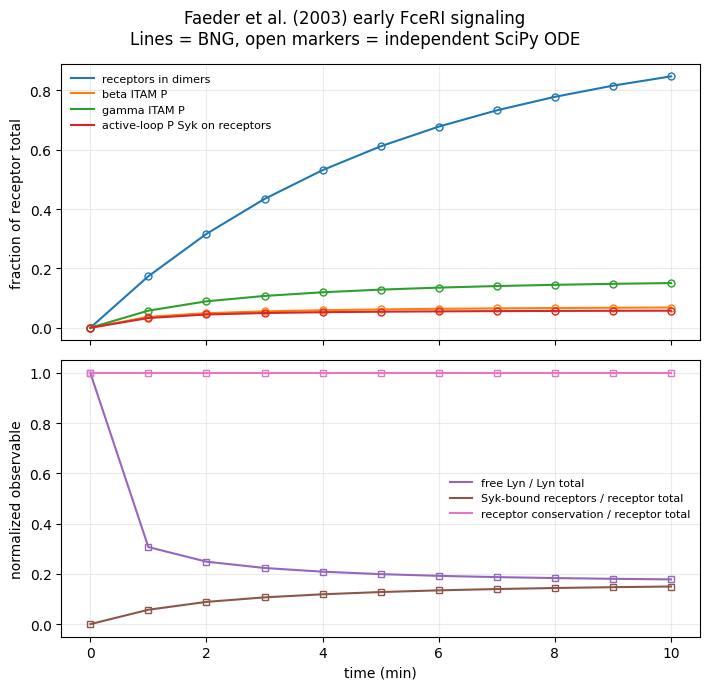

In [6]:
name_to_col = {name: i for i, name in enumerate(run_header)}
rec_tot = net["params"]["Rec_tot"]
lyn_tot = net["params"]["Lyn_tot"]

fig, axes = plt.subplots(2, 1, figsize=(7.2, 7.0), sharex=True)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

panel1 = [
    ("Obs_Rec_Dimer", "receptors in dimers"),
    ("Obs_Rec_BetaP", "beta ITAM P"),
    ("Obs_Rec_GammaP", "gamma ITAM P"),
    ("Obs_Rec_Syk_AloopP", "active-loop P Syk on receptors"),
]

for idx, (name, label) in enumerate(panel1):
    col = name_to_col[name]
    color = colors[idx % len(colors)]
    axes[0].plot(run_data[:, 0] / 60.0, run_data[:, col] / rec_tot, color=color, lw=1.5, label=label)
    axes[0].plot(
        t_eval / 60.0,
        independent_data[:, col] / rec_tot,
        linestyle="none",
        marker="o",
        mfc="none",
        mec=color,
        ms=5,
    )

panel2 = [
    ("Obs_Free_Lyn", "free Lyn / Lyn total", lyn_tot),
    ("Obs_Rec_Syk", "Syk-bound receptors / receptor total", rec_tot),
    ("Obs_Tot_Rec", "receptor conservation / receptor total", rec_tot),
]

for idx, (name, label, denom) in enumerate(panel2):
    col = name_to_col[name]
    color = colors[(idx + 4) % len(colors)]
    axes[1].plot(run_data[:, 0] / 60.0, run_data[:, col] / denom, color=color, lw=1.5, label=label)
    axes[1].plot(
        t_eval / 60.0,
        independent_data[:, col] / denom,
        linestyle="none",
        marker="s",
        mfc="none",
        mec=color,
        ms=5,
    )

axes[0].set_ylabel("fraction of receptor total")
axes[1].set_ylabel("normalized observable")
axes[1].set_xlabel("time (min)")
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle("Faeder et al. (2003) early FceRI signaling\nLines = BNG, open markers = independent SciPy ODE")
fig.tight_layout()
fig.savefig(PNG_FILE, dpi=200)
print(f"Saved {PNG_FILE.name}")
